# **GIAI ĐOẠN 1. EDA dữ liệu thô sau thu thập**

## **1. Import & Config**

In [2]:
from pathlib import Path
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

In [3]:
# Thiết lập cấu hình
set_configs()

DATA_FOLDER = (Path.cwd().resolve().parent.parent / 'data')
RAW_DIR = DATA_FOLDER / "data_raw"
FOODY_RAW_DIR = RAW_DIR / "foody_csv"
SHOPEE_RAW_DIR = RAW_DIR / "shopee_csv"
FOODY_C_DIR = FOODY_RAW_DIR / "C"
FOODY_D_DIR = FOODY_RAW_DIR / "D"

SHOPEE_C_DIR = SHOPEE_RAW_DIR / "C"
SHOPEE_D_DIR = SHOPEE_RAW_DIR / "D"

# File sau được tạo nhờ notebook define_address_v2.ipynb
AREA_MAPPING_PATH = Path("area_location_mapping.csv")

In [4]:
print("Data root:", DATA_FOLDER)
print("Foody C exists:", FOODY_C_DIR.exists())
print("Foody D exists:", FOODY_D_DIR.exists())
print("Shopee C exists:", SHOPEE_C_DIR.exists())
print("Shopee D exists:", SHOPEE_D_DIR.exists())
print("Mapping file:", AREA_MAPPING_PATH.exists())

Data root: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data
Foody C exists: True
Foody D exists: True
Shopee C exists: True
Shopee D exists: True
Mapping file: True


## **2. Load data**

Ở phần này, nhóm tiến hành đọc dữ liệu thô từ các thư mục `C` và `D` của hai nguồn Foody và ShopeeFood. Trong đó: 

- Thư mục `C` chứa dữ liệu về comments của khách hàng. 
- Thư mục `D` chứa dữ liệu thông tin cào được từ các dịch vụ ăn uống.

Sau khi đọc dữ liệu, nhóm sẽ gắn thêm các cột `source`, `province`, và `source_file` để theo dõi nguồn gốc của từng bản ghi.

### **2.1 Khai báo nguồn dữ liệu**

In [5]:
# Khai báo các nguồn dữ liệu thô
# Mỗi nguồn gồm:
# - comment_dir: thư mục chứa file C, tức dữ liệu comment/review
# - restaurant_dir: thư mục chứa file D, tức dữ liệu quán ăn/nhà hàng

DATA_SOURCES = {
    "foody": {
        "comment_dir": FOODY_C_DIR,
        "restaurant_dir": FOODY_D_DIR
    },
    "shopee": {
        "comment_dir": SHOPEE_C_DIR,
        "restaurant_dir": SHOPEE_D_DIR
    }
}

# Kiểm tra lại các đường dẫn dữ liệu
for source_name, paths in DATA_SOURCES.items():
    print(f"\nNguồn dữ liệu: {source_name}")
    print("Thư mục comment:", paths["comment_dir"], "| Tồn tại:", paths["comment_dir"].exists())
    print("Thư mục quán:", paths["restaurant_dir"], "| Tồn tại:", paths["restaurant_dir"].exists())


Nguồn dữ liệu: foody
Thư mục comment: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data\data_raw\foody_csv\C | Tồn tại: True
Thư mục quán: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data\data_raw\foody_csv\D | Tồn tại: True

Nguồn dữ liệu: shopee
Thư mục comment: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data\data_raw\shopee_csv\C | Tồn tại: True
Thư mục quán: D:\HOC_TREN_TRUONG\TIEN_XU_LY&XD_DL\DO_AN\notebook\DS108.Q21\data\data_raw\shopee_csv\D | Tồn tại: True


### **2.2 Đọc dữ liệu comment**

In [6]:
# Đọc và gộp toàn bộ file comment từ Foody và Shopee

comment_dfs = []
comment_file_errors = []

for source_name, paths in DATA_SOURCES.items():
    
    comment_files = get_data_files(paths["comment_dir"])
    
    for file in comment_files:
        try:
            df = read_data_file(file)
            
            # Gắn thông tin nguồn gốc dữ liệu
            df["source"] = source_name
            df["area_code"] = extract_area_code(file)
            df["source_file"] = file.name
            
            comment_dfs.append(df)
            
        except Exception as e:
            comment_file_errors.append({
                "source": source_name,
                "file_name": file.name,
                "error": str(e)
            })

raw_comments = pd.concat(comment_dfs, ignore_index=True)

print("Kích thước dữ liệu comment:", raw_comments.shape)
print("Số file comment bị lỗi:", len(comment_file_errors))

Kích thước dữ liệu comment: (105310, 9)
Số file comment bị lỗi: 0


### **2.4 Đọc dữ liệu quán** 

In [7]:
# Đọc và gộp toàn bộ file quán từ Foody và Shopee

restaurant_dfs = []
restaurant_file_errors = []

for source_name, paths in DATA_SOURCES.items():
    
    restaurant_files = get_data_files(paths["restaurant_dir"])
    
    for file in restaurant_files:
        try:
            df = read_data_file(file)
            
            # Gắn thông tin nguồn gốc dữ liệu
            df["source"] = source_name
            df["area_code"] = extract_area_code(file)
            df["source_file"] = file.name
            
            restaurant_dfs.append(df)
            
        except Exception as e:
            restaurant_file_errors.append({
                "source": source_name,
                "file_name": file.name,
                "error": str(e)
            })

raw_restaurants = pd.concat(restaurant_dfs, ignore_index=True)

print("Kích thước dữ liệu quán:", raw_restaurants.shape)
print("Số file quán bị lỗi:", len(restaurant_file_errors))

Kích thước dữ liệu quán: (18988, 27)
Số file quán bị lỗi: 0


### **2.5 Kiểm tra nhanh sau khi load data** 

In [8]:
# Kiểm tra kích thước của hai bảng dữ liệu sau khi load

print("Dữ liệu comment:")
print("- Số dòng:", raw_comments.shape[0])
print("- Số cột:", raw_comments.shape[1])

print("\nDữ liệu quán:")
print("- Số dòng:", raw_restaurants.shape[0])
print("- Số cột:", raw_restaurants.shape[1])

Dữ liệu comment:
- Số dòng: 105310
- Số cột: 9

Dữ liệu quán:
- Số dòng: 18988
- Số cột: 27


In [9]:
# Thống kê số lượng comment theo từng nguồn dữ liệu

comments_by_source = (
    raw_comments
    .groupby("source")
    .size()
    .reset_index(name="num_comments")
)

comments_by_source

,source,num_comments
0,foody,101985
1,shopee,3325


## **3. Merge province mapping** 

In [10]:
# Đọc file mapping mã khu vực - tỉnh/thành
# File này được tạo từ notebook define_address_v2.ipynb

area_mapping = pd.read_csv(AREA_MAPPING_PATH)
# Danh sách tỉnh ngoài phạm vi đề tài
provinces_to_drop = ['bạc liêu', 'cà mau', 'bến tre', 'bình phước']
area_mapping = area_mapping[~area_mapping['province'].str.lower().isin(provinces_to_drop)]
area_mapping.head()

,source,area_code,source_file,district_city,province
0,foody,10,D10.csv,Thành Phố Thủ Dầu Một,Bình Dương
1,foody,100,D100.csv,Quận 5,TP. HCM
2,foody,1000,D1000.csv,Thành Phố Long Xuyên,An Giang
3,foody,101,D101.csv,Quận Tân Phú,TP. HCM
4,foody,102,D102.csv,Quận 5,TP. HCM


In [11]:
# Chỉ giữ các cột cần thiết để merge theo tỉnh
# Không dùng district_city vì nhóm chỉ EDA theo tỉnh/thành

province_mapping = area_mapping[[
    "source",
    "area_code",
    "province"
]].drop_duplicates()

# Chuẩn hóa kiểu dữ liệu khóa merge
raw_comments["area_code"] = raw_comments["area_code"].astype(str)
raw_restaurants["area_code"] = raw_restaurants["area_code"].astype(str)
province_mapping["area_code"] = province_mapping["area_code"].astype(str)

raw_comments["source"] = raw_comments["source"].astype(str)
raw_restaurants["source"] = raw_restaurants["source"].astype(str)
province_mapping["source"] = province_mapping["source"].astype(str)

province_mapping.head()

,source,area_code,province
0,foody,10,Bình Dương
1,foody,100,TP. HCM
2,foody,1000,An Giang
3,foody,101,TP. HCM
4,foody,102,TP. HCM


In [12]:
# Gắn tỉnh/thành vào dữ liệu comment và dữ liệu quán

raw_comments = raw_comments.merge(
    province_mapping,
    on=["source", "area_code"],
    how="left"
)

raw_restaurants = raw_restaurants.merge(
    province_mapping,
    on=["source", "area_code"],
    how="left"
)

dataframes = [raw_comments, raw_restaurants, province_mapping]
for df in dataframes:
    try:
        mask = ~df['province'].str.lower().isin(provinces_to_drop)
    except:
        pass
    df.drop(df[~mask].index, inplace=True)

print("raw_comments sau khi merge:", raw_comments.shape)
print("raw_restaurants sau khi merge:", raw_restaurants.shape)

raw_comments sau khi merge: (105310, 10)
raw_restaurants sau khi merge: (18988, 28)


In [13]:
# Kiểm tra số dòng chưa map được tỉnh/thành

missing_province_comments = raw_comments[raw_comments["province"].isna()]
missing_province_restaurants = raw_restaurants[raw_restaurants["province"].isna()]

print("Số comment chưa map được tỉnh/thành:", missing_province_comments.shape[0])
print("Số quán chưa map được tỉnh/thành:", missing_province_restaurants.shape[0])

Số comment chưa map được tỉnh/thành: 0
Số quán chưa map được tỉnh/thành: 9


## **4. File-level overview**


In [14]:
# Tạo bảng thống kê từng file dữ liệu thô

file_summary = []

for source_name, paths in DATA_SOURCES.items():
    
    comment_files = get_data_files(paths["comment_dir"])
    restaurant_files = get_data_files(paths["restaurant_dir"])
    
    # File comment
    for file in comment_files:
        try:
            df = read_data_file(file)
            
            file_summary.append({
                "source": source_name,
                "data_type": "comment",
                "area_code": extract_area_code(file),
                "file_name": file.name,
                "num_rows": len(df),
                "num_columns": len(df.columns),
                "status": "ok"
            })
            
        except Exception as e:
            file_summary.append({
                "source": source_name,
                "data_type": "comment",
                "area_code": extract_area_code(file),
                "file_name": file.name,
                "num_rows": None,
                "num_columns": None,
                "status": str(e)
            })
    
    # File quán
    for file in restaurant_files:
        try:
            df = read_data_file(file)
            
            file_summary.append({
                "source": source_name,
                "data_type": "restaurant",
                "area_code": extract_area_code(file),
                "file_name": file.name,
                "num_rows": len(df),
                "num_columns": len(df.columns),
                "status": "ok"
            })
            
        except Exception as e:
            file_summary.append({
                "source": source_name,
                "data_type": "restaurant",
                "area_code": extract_area_code(file),
                "file_name": file.name,
                "num_rows": None,
                "num_columns": None,
                "status": str(e)
            })

file_summary_df = pd.DataFrame(file_summary)

file_summary_df = file_summary_df.merge(
    province_mapping,
    on=["source", "area_code"],
    how="left"
)

file_summary_df.head()

,source,data_type,area_code,file_name,num_rows,num_columns,status,province
0,foody,comment,10,C10.csv,37,6,ok,Bình Dương
1,foody,comment,100,C100.csv,1180,6,ok,TP. HCM
2,foody,comment,101,C101.csv,6037,6,ok,TP. HCM
3,foody,comment,102,C102.csv,90,6,ok,TP. HCM
4,foody,comment,103,C103.csv,5858,6,ok,TP. HCM


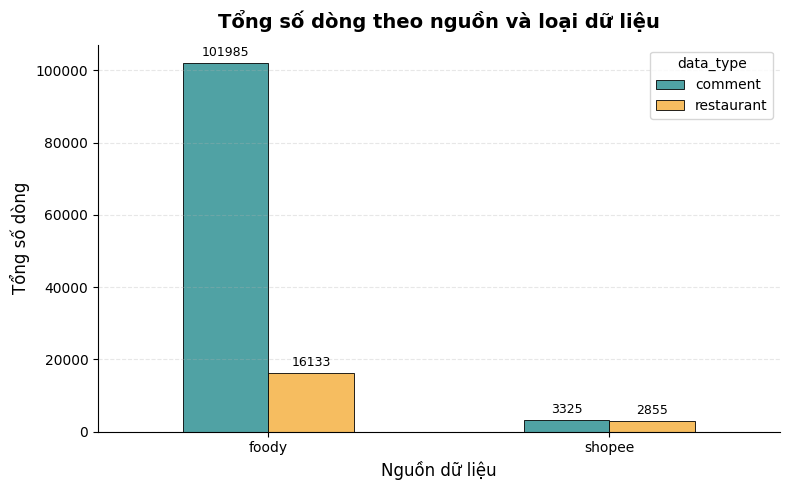

In [15]:
# Vẽ biểu đồ tổng số dòng theo nguồn và loại dữ liệu
plot_records_per_source(file_summary_df)

### **4.1 Tổng quan số file** 

In [16]:
# Tổng quan số file và số dòng theo nguồn dữ liệu

file_count_summary = (
    file_summary_df
    .groupby(["source", "data_type"])
    .agg(
        num_files=("file_name", "count"),
        total_rows=("num_rows", "sum"),
        min_rows=("num_rows", "min"),
        max_rows=("num_rows", "max"),
        avg_rows=("num_rows", "mean")
    )
    .reset_index()
)

file_count_summary

,source,data_type,num_files,total_rows,min_rows,max_rows,avg_rows
0,foody,comment,117,101985,0,8841,871.666667
1,foody,restaurant,117,16133,2,1076,137.888889
2,shopee,comment,87,3325,0,513,38.218391
3,shopee,restaurant,87,2855,0,200,32.816092


### **4.2 Kiểm tra file lỗi, file rỗng, file ít dữ liệu**

In [17]:
# Kiểm tra file bị lỗi đọc dữ liệu

error_files = file_summary_df[file_summary_df["status"] != "ok"]

print("Số file lỗi:", len(error_files))
error_files

Số file lỗi: 0


,source,data_type,area_code,file_name,num_rows,num_columns,status,province


In [18]:
# Kiểm tra file rỗng

empty_files = file_summary_df[
    (file_summary_df["status"] == "ok") &
    (file_summary_df["num_rows"] == 0)
]

print("Số file rỗng:", len(empty_files))
empty_files.head()

Số file rỗng: 39


,source,data_type,area_code,file_name,num_rows,num_columns,status,province
36,foody,comment,132,C132.csv,0,0,ok,Bình Dương
53,foody,comment,149,C149.csv,0,0,ok,Cần Thơ
54,foody,comment,150,C150.csv,0,0,ok,An Giang
56,foody,comment,152,C152.csv,0,0,ok,TP. HCM
58,foody,comment,154,C154.csv,0,0,ok,Cần Thơ


In [19]:
# Kiểm tra file có số dòng quá thấp

MIN_ROWS_THRESHOLD = 5

small_files = file_summary_df[
    (file_summary_df["status"] == "ok") &
    (file_summary_df["num_rows"] > 0) &
    (file_summary_df["num_rows"] < MIN_ROWS_THRESHOLD)
]

print("Số file có ít hơn", MIN_ROWS_THRESHOLD, "dòng:", len(small_files))
small_files.head()

Số file có ít hơn 5 dòng: 35


,source,data_type,area_code,file_name,num_rows,num_columns,status,province
95,foody,comment,231,C231.csv,1,6,ok,An Giang
105,foody,comment,69,C69.csv,1,6,ok,Bình Dương
190,foody,restaurant,210,D210.csv,2,24,ok,Cần Thơ
235,shopee,comment,10,C10.csv,1,6,ok,Bình Dương
238,shopee,comment,12,C12.csv,1,6,ok,Cần Thơ


## **5. Province-level overview**

### **5.1 Số quán và số comment theo tỉnh thành**

In [20]:
# Thống kê số comment theo nguồn và tỉnh/thành

comments_by_province = (
    raw_comments
    .groupby(["source", "province"])
    .size()
    .reset_index(name="num_comments")
)

# Thống kê số quán theo nguồn và tỉnh/thành

restaurants_by_province = (
    raw_restaurants
    .groupby(["source", "province"])
    .size()
    .reset_index(name="num_restaurants")
)

# Gộp hai bảng

province_summary = restaurants_by_province.merge(
    comments_by_province,
    on=["source", "province"],
    how="outer"
)

province_summary["num_restaurants"] = province_summary["num_restaurants"].fillna(0).astype(int)
province_summary["num_comments"] = province_summary["num_comments"].fillna(0).astype(int)

province_summary = province_summary.sort_values(
    ["source", "num_restaurants"],
    ascending=[True, False]
)

province_summary

,source,province,num_restaurants,num_comments
3,foody,TP. HCM,10549,84161
2,foody,Cần Thơ,1452,4017
1,foody,Bình Dương,1409,4294
4,foody,Vũng Tàu,1137,4097
5,foody,Đồng Nai,1049,4256
0,foody,An Giang,537,1160
9,shopee,TP. HCM,2325,2730
11,shopee,Đồng Nai,180,208
7,shopee,Bình Dương,139,87
8,shopee,Cần Thơ,120,235


### **5.2 Tỷ lệ dữ liệu theo tỉnh/thành**

In [21]:
# Tính tỷ lệ quán và tỷ lệ comment trong từng nguồn dữ liệu

province_summary["restaurant_ratio"] = (
    province_summary
    .groupby("source")["num_restaurants"]
    .transform(lambda x: x / x.sum())
)

province_summary["comment_ratio"] = (
    province_summary
    .groupby("source")["num_comments"]
    .transform(lambda x: x / x.sum())
)

province_summary_display = province_summary.copy()

province_summary_display["restaurant_ratio"] = (
    province_summary_display["restaurant_ratio"] * 100
).round(2)

province_summary_display["comment_ratio"] = (
    province_summary_display["comment_ratio"] * 100
).round(2)

province_summary_display = province_summary_display.rename(columns={
    "source": "Nguồn",
    "province": "Tỉnh/thành",
    "num_restaurants": "Số quán",
    "num_comments": "Số comment",
    "restaurant_ratio": "Tỷ lệ quán (%)",
    "comment_ratio": "Tỷ lệ comment (%)"
})

province_summary_display

,Nguồn,Tỉnh/thành,Số quán,Số comment,Tỷ lệ quán (%),Tỷ lệ comment (%)
3,foody,TP. HCM,10549,84161,65.39,82.52
2,foody,Cần Thơ,1452,4017,9.00,3.94
1,foody,Bình Dương,1409,4294,8.73,4.21
4,foody,Vũng Tàu,1137,4097,7.05,4.02
5,foody,Đồng Nai,1049,4256,6.50,4.17
0,foody,An Giang,537,1160,3.33,1.14
9,shopee,TP. HCM,2325,2730,81.69,82.11
11,shopee,Đồng Nai,180,208,6.32,6.26
7,shopee,Bình Dương,139,87,4.88,2.62
8,shopee,Cần Thơ,120,235,4.22,7.07


### **5.3 Số comment trung bình trên mỗi quán**

In [22]:
# Tính số comment trung bình trên mỗi quán theo tỉnh/thành

province_summary["avg_comments_per_restaurant"] = province_summary.apply(
    lambda row: row["num_comments"] / row["num_restaurants"]
    if row["num_restaurants"] > 0 else 0,
    axis=1
)

avg_comment_by_province = province_summary[[
    "source",
    "province",
    "num_restaurants",
    "num_comments",
    "avg_comments_per_restaurant"
]].copy()

avg_comment_by_province["avg_comments_per_restaurant"] = (
    avg_comment_by_province["avg_comments_per_restaurant"].round(2)
)

avg_comment_by_province = avg_comment_by_province.rename(columns={
    "source": "Nguồn",
    "province": "Tỉnh/thành",
    "num_restaurants": "Số quán",
    "num_comments": "Số comment",
    "avg_comments_per_restaurant": "Số comment trung bình/quán"
})

avg_comment_by_province

,Nguồn,Tỉnh/thành,Số quán,Số comment,Số comment trung bình/quán
3,foody,TP. HCM,10549,84161,7.98
2,foody,Cần Thơ,1452,4017,2.77
1,foody,Bình Dương,1409,4294,3.05
4,foody,Vũng Tàu,1137,4097,3.60
5,foody,Đồng Nai,1049,4256,4.06
0,foody,An Giang,537,1160,2.16
9,shopee,TP. HCM,2325,2730,1.17
11,shopee,Đồng Nai,180,208,1.16
7,shopee,Bình Dương,139,87,0.63
8,shopee,Cần Thơ,120,235,1.96


### **5.4 Biểu đồ số quán theo tỉnh/thành**

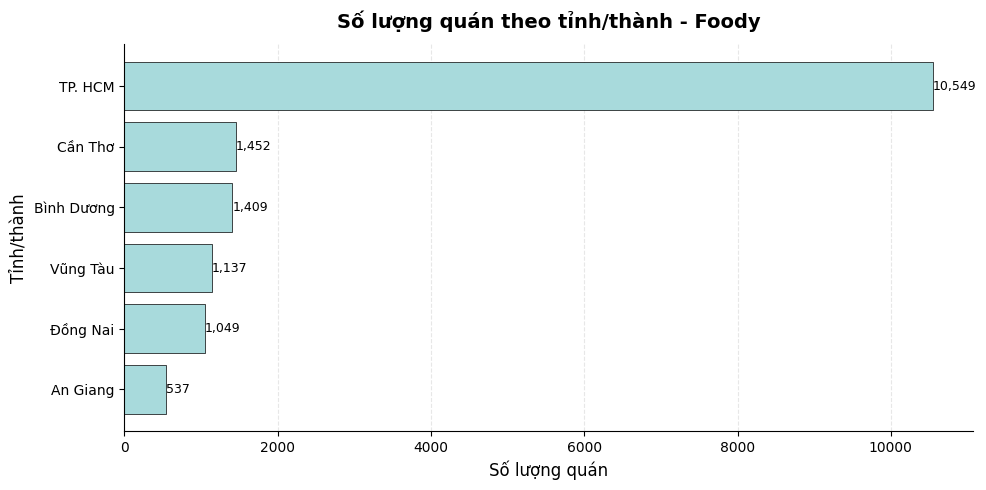

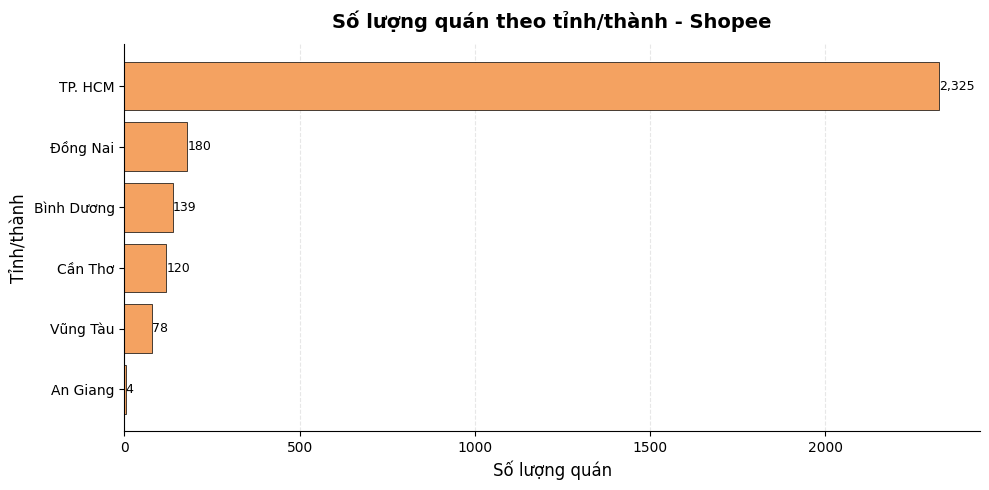

In [23]:
# Vẽ biểu đồ số lượng quán theo tỉnh/thành cho từng nguồn dữ liệu
# Chỉ lấy top 15 tỉnh/thành để biểu đồ gọn hơn

for source_name in province_summary["source"].unique():
    data_plot = province_summary[
        province_summary["source"] == source_name
    ]
    
    plot_barh_beautiful(
        data=data_plot,
        category_col="province",
        value_col="num_restaurants",
        title=f"Số lượng quán theo tỉnh/thành - {source_name.capitalize()}",
        xlabel="Số lượng quán",
        ylabel="Tỉnh/thành",
        color=PASTEL_COLORS.get(source_name, "#A8DADC"),
        top_n=15
    )

### **5.5 Biểu đồ số comment theo tỉnh/thành**

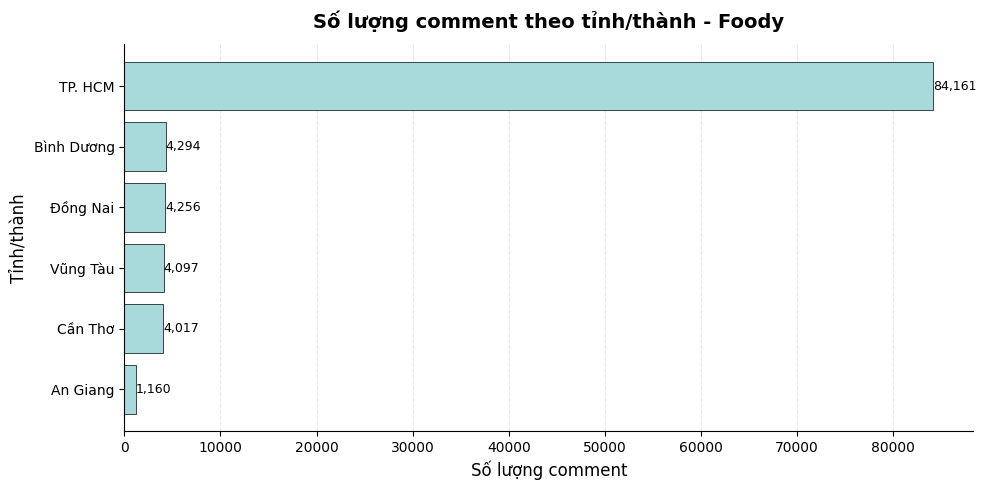

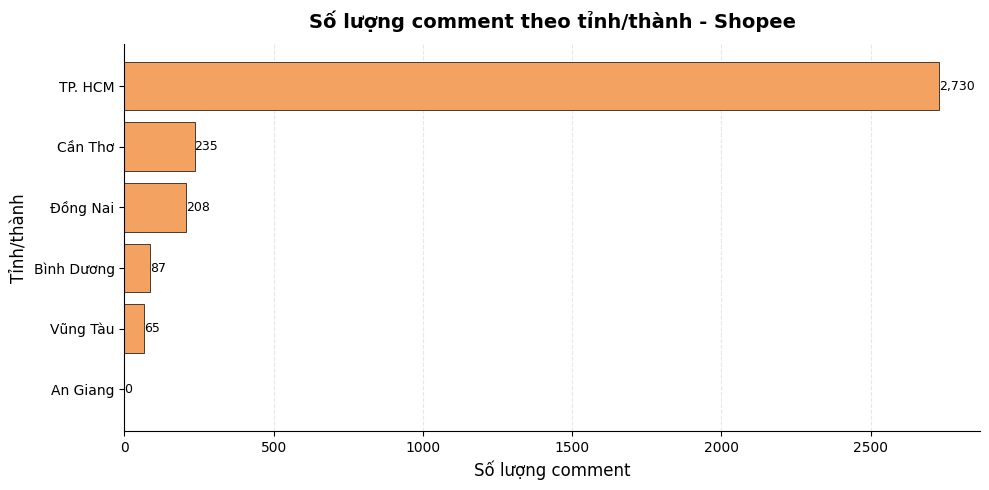

In [24]:
# Vẽ biểu đồ số lượng comment theo tỉnh/thành cho từng nguồn dữ liệu
# Chỉ lấy top 15 tỉnh/thành để biểu đồ dễ nhìn hơn

for source_name in province_summary["source"].unique():
    data_plot = province_summary[
        province_summary["source"] == source_name
    ]
    
    plot_barh_beautiful(
        data=data_plot,
        category_col="province",
        value_col="num_comments",
        title=f"Số lượng comment theo tỉnh/thành - {source_name.capitalize()}",
        xlabel="Số lượng comment",
        ylabel="Tỉnh/thành",
        color=PASTEL_COLORS.get(source_name, "#F4A261"),
        top_n=15
    )

### Nhận xét
* Ở 2 nền tảng tỉ lệ quán và bình luận ở TP.HCM luôn là lớn nhất
* Dữ liệu ở Foody nhiều hơn hẳn so với Shopee Food 

## **6. Schema checking**

In [25]:
# Kiểm tra schema của từng file

schema_summary = []

for source_name, paths in DATA_SOURCES.items():
    
    comment_files = get_data_files(paths["comment_dir"])
    restaurant_files = get_data_files(paths["restaurant_dir"])
    
    for file in comment_files:
        df = read_data_file(file)
        schema_summary.append({
            "source": source_name,
            "data_type": "comment",
            "file_name": file.name,
            "area_code": extract_area_code(file),
            "num_columns": len(df.columns),
            "columns": tuple(df.columns)
        })
    
    for file in restaurant_files:
        df = read_data_file(file)
        schema_summary.append({
            "source": source_name,
            "data_type": "restaurant",
            "file_name": file.name,
            "area_code": extract_area_code(file),
            "num_columns": len(df.columns),
            "columns": tuple(df.columns)
        })

# Chuyển danh sách schema thành DataFrame
schema_summary_df = pd.DataFrame(schema_summary)

# Đếm số schema khác nhau, bỏ qua các file rỗng
schema_count_summary = (
    schema_summary_df[
        schema_summary_df["num_columns"] > 0
    ]
    .groupby(["source", "data_type"])["columns"]
    .nunique()
    .reset_index(name="num_unique_schemas")
)

schema_count_summary

,source,data_type,num_unique_schemas
0,foody,comment,1
1,foody,restaurant,2
2,shopee,comment,1
3,shopee,restaurant,1


In [26]:
# Gom các file có cùng schema lại với nhau

schema_groups = (
    schema_summary_df
    .groupby(["source", "data_type", "columns"])
    .agg(
        num_files=("file_name", "count"),
        files=("file_name", list)
    )
    .reset_index()
    .sort_values(["source", "data_type", "num_files"], ascending=[True, True, False])
)

schema_groups

,source,data_type,columns,num_files,files
1,foody,comment,"(UserID, User, Review Time, Rating (10), Comment, RestaurantID)",111,"[C10.csv, C100.csv, C101.csv, C102.csv, C103.csv, C104.csv, C105.csv, C106.csv, C107.csv, C108.csv, C109.csv, C11.csv, C110.csv, C111.csv, C112.cs..."
0,foody,comment,(),6,"[C132.csv, C149.csv, C150.csv, C152.csv, C154.csv, C210.csv]"
3,foody,restaurant,"(RestaurantID, Restaurant Name, Latitude, Longitude, Address, Type, Cuisines, Style, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunda...",86,"[D101.csv, D102.csv, D103.csv, D104.csv, D105.csv, D106.csv, D107.csv, D108.csv, D109.csv, D110.csv, D111.csv, D112.csv, D113.csv, D114.csv, D115...."
2,foody,restaurant,"(RestaurantID, Restaurant Name, Latitude, Longitude, Address, Type, Cuisines, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday, Styl...",31,"[D10.csv, D100.csv, D11.csv, D12.csv, D13.csv, D17.csv, D18.csv, D19.csv, D20.csv, D21.csv, D22.csv, D24.csv, D26.csv, D32.csv, D38.csv, D46.csv, ..."
4,shopee,comment,"(UserID, User, Review Time, Rating (10), Comment, RestaurantID)",87,"[C1.csv, C10.csv, C100.csv, C11.csv, C12.csv, C13.csv, C14.csv, C15.csv, C16.csv, C17.csv, C18.csv, C19.csv, C2.csv, C20.csv, C21.csv, C22.csv, C2..."
5,shopee,restaurant,"(RestaurantID, Restaurant Name, Latitude, Longitude, Address, Type, Cuisines, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, Sunday, Styl...",87,"[D1.csv, D10.csv, D100.csv, D11.csv, D12.csv, D13.csv, D14.csv, D15.csv, D16.csv, D17.csv, D18.csv, D19.csv, D2.csv, D20.csv, D21.csv, D22.csv, D2..."


## **7. Missing values analysis**

### **7.1 Missing trong comment**

In [27]:
# Kiểm tra giá trị thiếu trong dữ liệu comment

missing_comments = (
    raw_comments
    .isna()
    .sum()
    .reset_index()
)

missing_comments.columns = ["column", "missing_count"]
missing_comments["missing_ratio"] = missing_comments["missing_count"] / len(raw_comments)

missing_comments = missing_comments.sort_values("missing_count", ascending=False)

missing_comments_display = missing_comments[
    missing_comments["missing_count"] > 0
].copy()

missing_comments_display["missing_ratio"] = (
    missing_comments_display["missing_ratio"] * 100
).round(2)

missing_comments_display

,column,missing_count,missing_ratio
4,Comment,304,0.29
1,User,286,0.27
2,Review Time,285,0.27
3,Rating (10),44,0.04


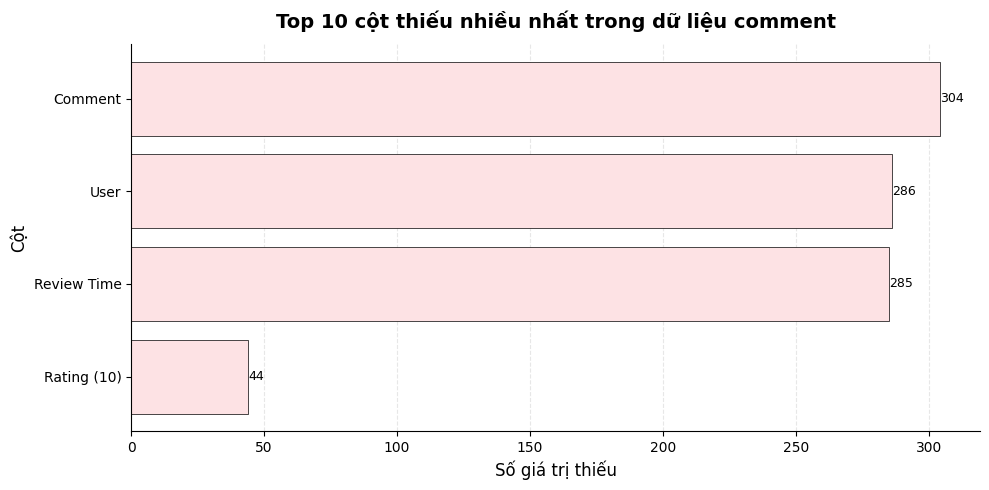

In [28]:
# Vẽ top 10 cột có nhiều giá trị thiếu trong dữ liệu comment

missing_comments_top = missing_comments_display.sort_values(
    "missing_count",
    ascending=False
).head(10)

plot_barh_beautiful(
    data=missing_comments_top,
    category_col="column",
    value_col="missing_count",
    title="Top 10 cột thiếu nhiều nhất trong dữ liệu comment",
    xlabel="Số giá trị thiếu",
    ylabel="Cột",
    color="#FDE2E4",
    top_n=None, 
    save_img=True,
    prefix='comments'
)

### **7.2 Missing trong quán**

In [29]:
# Kiểm tra giá trị thiếu trong dữ liệu quán

missing_restaurants = (
    raw_restaurants
    .isna()
    .sum()
    .reset_index()
)

missing_restaurants.columns = ["column", "missing_count"]
missing_restaurants["missing_ratio"] = missing_restaurants["missing_count"] / len(raw_restaurants)

missing_restaurants = missing_restaurants.sort_values("missing_count", ascending=False)

missing_restaurants_display = missing_restaurants[
    missing_restaurants["missing_count"] > 0
].copy()

missing_restaurants_display["missing_ratio"] = (
    missing_restaurants_display["missing_ratio"] * 100
).round(2)

missing_restaurants_display

,column,missing_count,missing_ratio
14,Style,4213,22.19
18,Price,1618,8.52
13,Sunday,1052,5.54
6,Cuisines,936,4.93
12,Saturday,542,2.85
11,Friday,528,2.78
7,Monday,528,2.78
9,Wednesday,528,2.78
10,Thursday,528,2.78
8,Tuesday,528,2.78


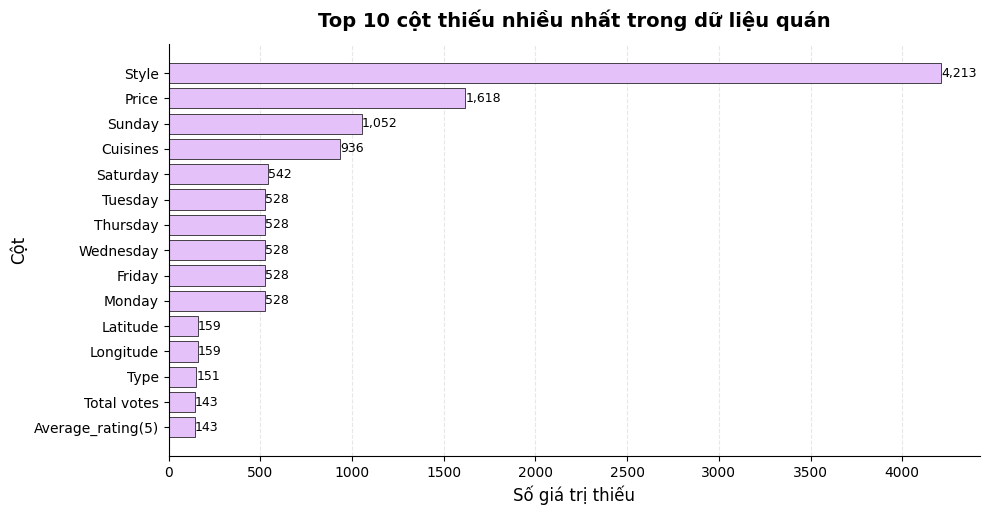

In [30]:
# Vẽ top 10 cột có nhiều giá trị thiếu trong dữ liệu quán

missing_restaurants_top = missing_restaurants_display.sort_values(
    "missing_count",
    ascending=False
).head(20)

plot_barh_beautiful(
    data=missing_restaurants_top,
    category_col="column",
    value_col="missing_count",
    title="Top 10 cột thiếu nhiều nhất trong dữ liệu quán",
    xlabel="Số giá trị thiếu",
    ylabel="Cột",
    color="#E4C1F9",
    top_n=15,
    save_img=True
)

### **7.3 Missing ở cột quan trọng** 

In [31]:
# Các cột quan trọng trong dữ liệu comment

important_comment_cols = [
    "RestaurantID",
    "Comment",
    "Rating (10)",
    "Review Time"
]

important_comment_cols = [
    col for col in important_comment_cols
    if col in raw_comments.columns
]

raw_comments[important_comment_cols].isna().sum()

RestaurantID      0
Comment         304
Rating (10)      44
Review Time     285
dtype: int64

In [32]:
# Các cột quan trọng trong dữ liệu quán

important_restaurant_cols = [
    "RestaurantID",
    "Restaurant Name",
    "Address",
    "Type",
    "Cuisines",
    "Average_rating"
]

important_restaurant_cols = [
    col for col in important_restaurant_cols
    if col in raw_restaurants.columns
]

raw_restaurants[important_restaurant_cols].isna().sum()

RestaurantID         0
Restaurant Name     47
Address             47
Type               151
Cuisines           936
dtype: int64

## **8. Duplicate analysis**

### **8.1 Trùng comment**

In [33]:
# Kiểm tra trùng comment dựa trên nguồn, khu vực, quán, người dùng và nội dung comment
# Việc thêm source và area_code giúp tránh nhầm các quán có cùng RestaurantID ở các file khác nhau

comment_duplicate_cols = [
    "source",
    "area_code",
    "RestaurantID",
    "UserID",
    "Comment"
]

comment_duplicate_cols = [
    col for col in comment_duplicate_cols
    if col in raw_comments.columns
]

duplicate_comments_mask = raw_comments.duplicated(
    subset=comment_duplicate_cols,
    keep=False
)

duplicate_comments = raw_comments[duplicate_comments_mask]

print("Số dòng comment bị trùng:", duplicate_comments.shape[0])

duplicate_comments.head()

Số dòng comment bị trùng: 1575


,UserID,User,Review Time,Rating (10),Comment,RestaurantID,source,area_code,source_file,province
103113,1,Ngo Chiphat,3/5/2023 20:33,6.8,Thấy quán gần nhà nên thử vì thấy bữa giờ quảng cáo rầm rộ lắm... Cà phê vị cũng đậm phần kem mới là hồn của ly cà phê... Vị mặn mặn béo béo.. khô...,16,shopee,3,C3.csv,TP. HCM
103114,1,Ngo Chiphat,3/5/2023 20:33,6.8,Thấy quán gần nhà nên thử vì thấy bữa giờ quảng cáo rầm rộ lắm... Cà phê vị cũng đậm phần kem mới là hồn của ly cà phê... Vị mặn mặn béo béo.. khô...,16,shopee,3,C3.csv,TP. HCM
103115,1,Ngo Chiphat,3/5/2023 20:33,6.8,Thấy quán gần nhà nên thử vì thấy bữa giờ quảng cáo rầm rộ lắm... Cà phê vị cũng đậm phần kem mới là hồn của ly cà phê... Vị mặn mặn béo béo.. khô...,16,shopee,3,C3.csv,TP. HCM
103116,1,Ngo Chiphat,3/5/2023 20:33,6.8,Thấy quán gần nhà nên thử vì thấy bữa giờ quảng cáo rầm rộ lắm... Cà phê vị cũng đậm phần kem mới là hồn của ly cà phê... Vị mặn mặn béo béo.. khô...,16,shopee,3,C3.csv,TP. HCM
103117,1,Ngo Chiphat,3/5/2023 20:33,6.8,Thấy quán gần nhà nên thử vì thấy bữa giờ quảng cáo rầm rộ lắm... Cà phê vị cũng đậm phần kem mới là hồn của ly cà phê... Vị mặn mặn béo béo.. khô...,16,shopee,3,C3.csv,TP. HCM


In [34]:
# Số dòng comment trùng có thể loại bỏ nếu giữ dòng đầu tiên

duplicate_comments_to_remove = raw_comments.duplicated(
    subset=comment_duplicate_cols,
    keep="first"
).sum()

print("Số dòng comment trùng có thể loại bỏ:", duplicate_comments_to_remove)

Số dòng comment trùng có thể loại bỏ: 1190


### **8.2 Trùng quán**

In [35]:
# Kiểm tra trùng quán dựa trên source, area_code và RestaurantID

restaurant_id_duplicate_cols = [
    "source",
    "area_code",
    "RestaurantID"
]

restaurant_id_duplicate_cols = [
    col for col in restaurant_id_duplicate_cols
    if col in raw_restaurants.columns
]

duplicate_restaurant_id_mask = raw_restaurants.duplicated(
    subset=restaurant_id_duplicate_cols,
    keep=False
)

duplicate_restaurant_id = raw_restaurants[duplicate_restaurant_id_mask]

print("Số dòng quán bị trùng theo source + area_code + RestaurantID:", duplicate_restaurant_id.shape[0])

duplicate_restaurant_id.head()

Số dòng quán bị trùng theo source + area_code + RestaurantID: 5903


,RestaurantID,Restaurant Name,Latitude,Longitude,Address,Type,Cuisines,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Style,Has_Online_delivery,Has_Table_booking,Has_Wifi,Price,Product_quality(10),Serving_quality(10),Interior_design(10),Average_rating(5),Total votes,source,area_code,source_file,province
216,25,Kichi Kichi Lẩu Băng Chuyền - Nguyễn Văn Trỗi,10.796808,106.673216,"197 Nguyễn Văn Trỗi, P. 10, Quận Phú Nhuận, TP. HCM","Nhà hàng,","Thịt Gà, Thịt Bò, Hải sản, Lẩu,",10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,"Món Á, Món Nhật,",no,yes,yes,150.000 -308.000,9.0,9.0,9.0,9.0,414,foody,101,D101.csv,TP. HCM
217,25,Kichi Kichi Lẩu Băng Chuyền - Vincom Center,10.77742,106.701987,"Tầng B3 Vincom Center, 72 Lê Thánh Tôn, P. Bến Nghé, Quận 1, TP. HCM","Nhà hàng,","Thịt Gà, Thịt Bò, Thịt Heo, Hải sản, Lẩu,","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","Món Á, Món Nhật,",no,yes,no,149.000 -250.000,8.3,8.3,8.0,8.2,400,foody,101,D101.csv,TP. HCM
218,25,Kichi Kichi Lẩu Băng Chuyền - Phú Mỹ Hưng,10.722907,106.710213,"153 Nguyễn Đức Cảnh, P. Tân Phong, Quận 7, TP. HCM","Nhà hàng,","Thịt Gà, Thịt Bò, Thịt Heo, Hải sản, Lẩu,","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","Món Á, Món Nhật,",no,yes,yes,149.000 -308.000,7.3,7.2,7.2,7.3,106,foody,101,D101.csv,TP. HCM
219,25,Kichi Kichi Lẩu Băng Chuyền - Sư Vạn Hạnh,10.77645,106.666684,"830 Sư Vạn Hạnh, P. 13, Quận 10, TP. HCM","Nhà hàng,","Thịt Gà, Thịt Bò, Thịt Heo, Hải sản, Lẩu,","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","17:00 - 22:00, 17:00 - 22:00","Món Á, Món Nhật,",no,yes,yes,149.000 -308.000,8.1,8.0,8.1,8.1,390,foody,101,D101.csv,TP. HCM
220,25,Kichi Kichi Lẩu Băng Chuyền - Phan Xích Long,10.797645,106.689584,"145 Phan Xích Long, P. 2, Quận Phú Nhuận, TP. HCM","Nhà hàng,","Thịt Gà, Thịt Bò, Thịt Heo, Hải sản, Lẩu,","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","10:00 - 17:00, 17:00 - 22:00","Món Á, Món Nhật,",no,yes,yes,149.000 -308.000,7.2,7.0,7.2,7.2,247,foody,101,D101.csv,TP. HCM


In [36]:
# Kiểm tra trùng quán dựa trên tên quán và latitude, longitude

restaurant_duplicate_cols = [
    "Restaurant Name",
    "Latitude",
    "Longitude"
]

restaurant_duplicate_cols = [
    col for col in restaurant_duplicate_cols
    if col in raw_restaurants.columns
]

duplicate_restaurants_mask = raw_restaurants.duplicated(
    subset=restaurant_duplicate_cols,
    keep=False
)

duplicate_restaurants = raw_restaurants[duplicate_restaurants_mask]

print("Số dòng quán bị trùng theo tên và tọa độ:", duplicate_restaurants.shape[0])
duplicate_restaurants.head()

Số dòng quán bị trùng theo tên và tọa độ: 6318


,RestaurantID,Restaurant Name,Latitude,Longitude,Address,Type,Cuisines,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Style,Has_Online_delivery,Has_Table_booking,Has_Wifi,Price,Product_quality(10),Serving_quality(10),Interior_design(10),Average_rating(5),Total votes,source,area_code,source_file,province
0,1,188 Hongkong Dimsum,10.978349,106.66074,"249 Thích Quảng Đức, P. Chánh Nghĩa, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,"Bún , Hủ tiếu , Mì , Dimsum , Cơm văn phòng , Cơm",06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,"Món Á , Món Trung Hoa",no,yes,no,12.000đ - 65.000,3.0,3.0,3.5,4.0,2,foody,10,D10.csv,Bình Dương
22,23,Há Cảo & Dimsum - Dung Đại Gia 3 Con - Shop Online,10.895034,106.79369,"39/2/80 Đường Thống Nhất, Khu Phố Nội Hoá 1, P. Bình An, Thị Xã Dĩ An, Bình Dương",Quán ăn,Dimsum,08:00 - 22:00,08:00 - 22:00,08:00 - 22:00,08:00 - 22:00,08:00 - 22:00,08:00 - 22:00,08:00 - 22:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
23,24,Ẩm Thực Hùng Thanh,11.13686,106.613291,"2 Đường DA1-2, Thị Xã Bến Cát, Bình Dương",Quán ăn,"Món nước , Dimsum",09:00 - 21:00,09:00 - 21:00,09:00 - 21:00,09:00 - 21:00,09:00 - 21:00,09:00 - 21:00,09:00 - 21:00,"Món Á , Đài Loan",no,no,yes,30.000đ - 60.000,9.0,8.0,9.0,8.8,1,foody,10,D10.csv,Bình Dương
29,30,Kebab Torki - Trần Hưng Đạo,10.901652,106.775818,"286-288 Trần Hưng Đạo, Khu Phố Đông B, P. Đông Hoà, Thị Xã Dĩ An, Bình Dương",Ăn vặt/vỉa hè,"Bánh mì , Hamburger , Bánh - Kẹo , Ăn vặt - Ăn nhẹ , Cá/bò viên , Fastfood - Thức ăn nhanh",06:00 - 20:30,06:00 - 20:30,06:00 - 20:30,06:00 - 20:30,06:00 - 20:30,06:00 - 20:30,06:00 - 20:30,NaN,no,yes,yes,15.000đ - 50.000,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
38,39,Bamboo Dimsum - Aeon Mall Bình Dương,10.931793,106.711701,"Tầng 2 Aeon Mall Bình Dương, 1 Đại Lộ Bình Dương, P. Thuận Giao, Thị Xã Thuận An, Bình Dương",Nhà hàng,"Bún , Mì , Bánh bao , Bánh - Kẹo , Dimsum",10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,10:00 - 22:00,09:00 - 22:00,09:00 - 22:00,Món Á,no,no,yes,15.000đ - 45.000,3.3,1.3,4.3,3.9,3,foody,10,D10.csv,Bình Dương


## **9. Relationship between comments and restaurants**

### **9.1 Comment không liên kết được với quán**

In [37]:
# Kiểm tra comment có liên kết được với quán không
# Khóa liên kết đúng là source + area_code + RestaurantID
restaurant_keys = set(
    raw_restaurants[["source", "area_code", "RestaurantID"]]
    .dropna()
    .astype(str)
    .apply(tuple, axis=1)
)

comment_keys = (
    raw_comments[["source", "area_code", "RestaurantID"]]
    .dropna()
    .astype(str)
    .apply(tuple, axis=1)
)

comments_without_restaurant = raw_comments[
    ~comment_keys.isin(restaurant_keys)
]

print("Số comment không liên kết được với quán:", comments_without_restaurant.shape[0])

comments_without_restaurant.head()

Số comment không liên kết được với quán: 0


,UserID,User,Review Time,Rating (10),Comment,RestaurantID,source,area_code,source_file,province


### **9.2 Quán không có comment**

In [38]:
# Kiểm tra quán không có comment nào
# Khóa liên kết đúng là source + area_code + RestaurantID

comment_restaurant_keys = set(
    raw_comments[["source", "area_code", "RestaurantID"]]
    .dropna()
    .astype(str)
    .apply(tuple, axis=1)
)

restaurant_keys_series = (
    raw_restaurants[["source", "area_code", "RestaurantID"]]
    .dropna()
    .astype(str)
    .apply(tuple, axis=1)
)

restaurants_without_comments = raw_restaurants[
    ~restaurant_keys_series.isin(comment_restaurant_keys)
]

print("Số quán không có comment:", restaurants_without_comments.shape[0])

restaurants_without_comments.head()

Số quán không có comment: 4840


,RestaurantID,Restaurant Name,Latitude,Longitude,Address,Type,Cuisines,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Style,Has_Online_delivery,Has_Table_booking,Has_Wifi,Price,Product_quality(10),Serving_quality(10),Interior_design(10),Average_rating(5),Total votes,source,area_code,source_file,province
1,2,Dimsum Hân Hân - Há Cảo & Xíu Mại - Cách Mạng Tháng Tám,10.914844,106.696614,"B70B Cách Mạng Tháng 8, P. Bình Nhâm, Thị Xã Thuận An, Bình Dương",Ăn vặt/vỉa hè,"Bánh bao , Bánh - Kẹo , Dimsum",08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,NaN,no,yes,yes,8.000đ - 50.000,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
2,3,Bao Hot Pot - Hainan Haus Sora Gardens,11.047113,106.679094,"Tầng Trệt Toà Nhà Sora Gardens II, Lô C17 Đại Lộ Hùng Vương, P. Phú Mỹ, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,Dimsum,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
3,4,Đậu Hủ Thối Đài Loan - KDC Việt Sing,10.942403,106.730415,"Ô 47 - DC29 Đường D1, KDC Việt Sing, P. An Phú, Thị Xã Thuận An, Bình Dương",Quán ăn,"Bún , Mì , Dimsum , Ăn vặt - Ăn nhẹ , Nem",11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
4,5,Phá Lấu Vinh Bụng Bự (Quán Gốc) - Phạm Ngũ Lão,10.982969,106.654574,"21 Phạm Ngũ Lão, P. Phú Cường, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,"Bánh mì , Bánh - Kẹo , Dimsum , Ăn vặt - Ăn nhẹ , Nem , Cá/bò viên",16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương
5,6,Mì Sủi Cảo A Bư - Trần Văn Ơn,10.979249,106.675735,"168 Trần Văn Ơn, P. Phú Lợi, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,"Bún , Mì , Dimsum , Cơm",06:00 - 13:00,06:00 - 13:00,06:00 - 13:00,06:00 - 13:00,06:00 - 13:00,06:00 - 13:00,06:00 - 13:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương


### **9.3 Số comment trên mỗi quán**

In [39]:
# Đếm số comment theo từng quán
# Nhóm theo source + area_code + RestaurantID để tránh nhầm quán giữa các file
comments_per_restaurant = (
    raw_comments
    .groupby(["source", "area_code", "RestaurantID"])
    .size()
    .reset_index(name="num_comments")
)

restaurant_comment_summary = raw_restaurants.merge(
    comments_per_restaurant,
    on=["source", "area_code", "RestaurantID"],
    how="left"
)

restaurant_comment_summary["num_comments"] = (
    restaurant_comment_summary["num_comments"]
    .fillna(0)
    .astype(int)
)

display(restaurant_comment_summary["num_comments"].describe())
display(restaurant_comment_summary.head())

count    18988.000000
mean        27.328734
std         41.894457
min          0.000000
25%          0.000000
50%         10.000000
75%         25.000000
max        135.000000
Name: num_comments, dtype: float64

,RestaurantID,Restaurant Name,Latitude,Longitude,Address,Type,Cuisines,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday,Style,Has_Online_delivery,Has_Table_booking,Has_Wifi,Price,Product_quality(10),Serving_quality(10),Interior_design(10),Average_rating(5),Total votes,source,area_code,source_file,province,num_comments
0,1,188 Hongkong Dimsum,10.978349,106.66074,"249 Thích Quảng Đức, P. Chánh Nghĩa, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,"Bún , Hủ tiếu , Mì , Dimsum , Cơm văn phòng , Cơm",06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,06:00 - 22:00,"Món Á , Món Trung Hoa",no,yes,no,12.000đ - 65.000,3.0,3.0,3.5,4.0,2,foody,10,D10.csv,Bình Dương,2
1,2,Dimsum Hân Hân - Há Cảo & Xíu Mại - Cách Mạng Tháng Tám,10.914844,106.696614,"B70B Cách Mạng Tháng 8, P. Bình Nhâm, Thị Xã Thuận An, Bình Dương",Ăn vặt/vỉa hè,"Bánh bao , Bánh - Kẹo , Dimsum",08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,08:00 - 20:00,NaN,no,yes,yes,8.000đ - 50.000,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương,0
2,3,Bao Hot Pot - Hainan Haus Sora Gardens,11.047113,106.679094,"Tầng Trệt Toà Nhà Sora Gardens II, Lô C17 Đại Lộ Hùng Vương, P. Phú Mỹ, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,Dimsum,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,11:00 - 14:00\r\n16:00 - 21:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương,0
3,4,Đậu Hủ Thối Đài Loan - KDC Việt Sing,10.942403,106.730415,"Ô 47 - DC29 Đường D1, KDC Việt Sing, P. An Phú, Thị Xã Thuận An, Bình Dương",Quán ăn,"Bún , Mì , Dimsum , Ăn vặt - Ăn nhẹ , Nem",11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,11:00 - 21:00,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương,0
4,5,Phá Lấu Vinh Bụng Bự (Quán Gốc) - Phạm Ngũ Lão,10.982969,106.654574,"21 Phạm Ngũ Lão, P. Phú Cường, Thành Phố Thủ Dầu Một, Bình Dương",Quán ăn,"Bánh mì , Bánh - Kẹo , Dimsum , Ăn vặt - Ăn nhẹ , Nem , Cá/bò viên",16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,16:00 - 21:30,NaN,no,no,no,NaN,0.0,0.0,0.0,_._,0,foody,10,D10.csv,Bình Dương,0


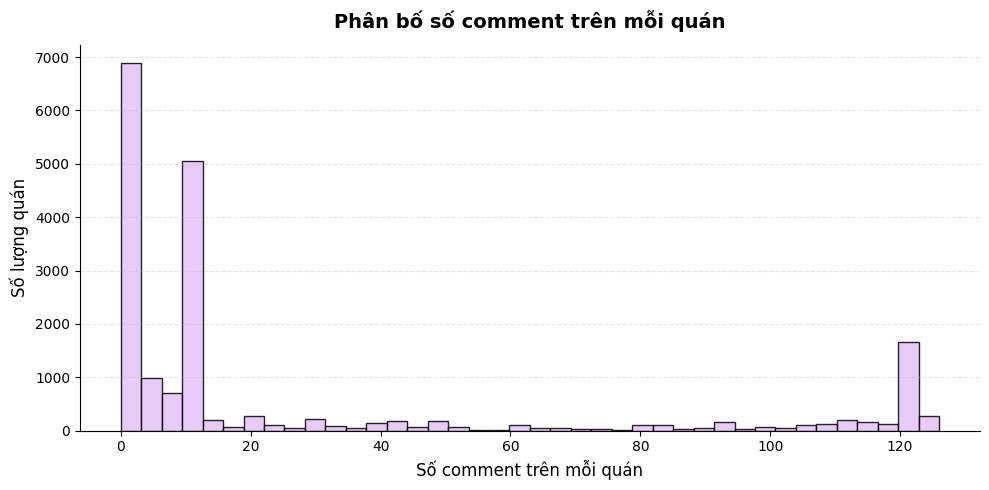

In [40]:
# Vẽ phân bố số comment trên mỗi quán sau khi giới hạn ở percentile 99
upper_limit = restaurant_comment_summary["num_comments"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    restaurant_comment_summary[
        restaurant_comment_summary["num_comments"] <= upper_limit
    ]["num_comments"],
    bins=40,
    color=PASTEL_COLORS["accent"],
    edgecolor="black",
    alpha=0.85
)

plt.title("Phân bố số comment trên mỗi quán", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Số comment trên mỗi quán")
plt.ylabel("Số lượng quán")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## **10. Text overview for comments**

In [41]:
# Tính độ dài comment theo số ký tự và số từ

raw_comments["comment_char_length"] = (
    raw_comments["Comment"]
    .astype(str)
    .str.len()
)

raw_comments["comment_word_count"] = (
    raw_comments["Comment"]
    .astype(str)
    .str.split()
    .str.len()
)

display(raw_comments[[
    "comment_char_length",
    "comment_word_count"
]].describe())

display(raw_comments.head())

,comment_char_length,comment_word_count
count,105006.000000,105006.000000
mean,338.344790,75.961107
std,346.642057,78.068184
min,1.000000,1.000000
25%,125.000000,28.000000
50%,252.000000,56.000000
75%,473.000000,106.000000
max,22788.000000,5171.000000


,UserID,User,Review Time,Rating (10),Comment,RestaurantID,source,area_code,source_file,province,comment_char_length,comment_word_count
0,1,Bella Phan,26/9/2019 10:44,5.6,"Quán đang được quảng cáo nhiều ở bd nên đi ăn thử. Các món cũng bth, không có món nào đặc biệt ngon hay nổi trội hơn các món khác. Mì soup không n...",1,foody,10,C10.csv,Bình Dương,332.0,77.0
1,2,Trinh Hồ,20/9/2019 17:18,2.4,Mình đã vào quán được một lần và đây là trải nghiệm của bản thân mình.\r\nMón ăn: Gọi 4 món thì đã có 2 món hết ( cái này mình không bàn nhiều vì ...,1,foody,10,C10.csv,Bình Dương,738.0,169.0
2,3,AXM Nhân,3/8/2020 17:25,8.8,"Hổm rày đi đổi gió về Bình Dương thì gặp quán này, thấy cũng lạ nên vào thử, ai dè ghiền thiệt 🤩\r\n\r\nMình kêu 5 món, với kinh nghiệm của một ng...",24,foody,10,C10.csv,Bình Dương,361.0,84.0
3,4,Eira Huang,10/12/2023 13:18,10.0,"Món ăn ở đây rất ngon, chuẩn vị Tứ Xuyên Trung Quốc. Giá cả lại phải chăng.",32,foody,10,C10.csv,Bình Dương,75.0,17.0
4,5,Vinga,1/1/2019 20:15,5.2,Cảm xúc sau khi thừng thức là cực dở tệ,39,foody,10,C10.csv,Bình Dương,39.0,10.0


In [42]:
# Kiểm tra comment quá ngắn
# Những comment quá ngắn có thể không đủ thông tin để phân tích cảm xúc

short_comments = raw_comments[
    raw_comments["comment_word_count"] <= 2
]

print("Số comment có từ 2 từ trở xuống:", short_comments.shape[0])

short_comments[[
    "RestaurantID",
    "Comment",
    "comment_word_count"
]].head(20)

Số comment có từ 2 từ trở xuống: 1644


,RestaurantID,Comment,comment_word_count
13,45,Quá ngon,2.0
41,1,Ăn ổn,2.0
127,8,f,1.0
128,8,F,1.0
129,8,k,1.0
130,8,R,1.0
131,8,R,1.0
132,8,R,1.0
133,8,R,1.0
134,8,R,1.0


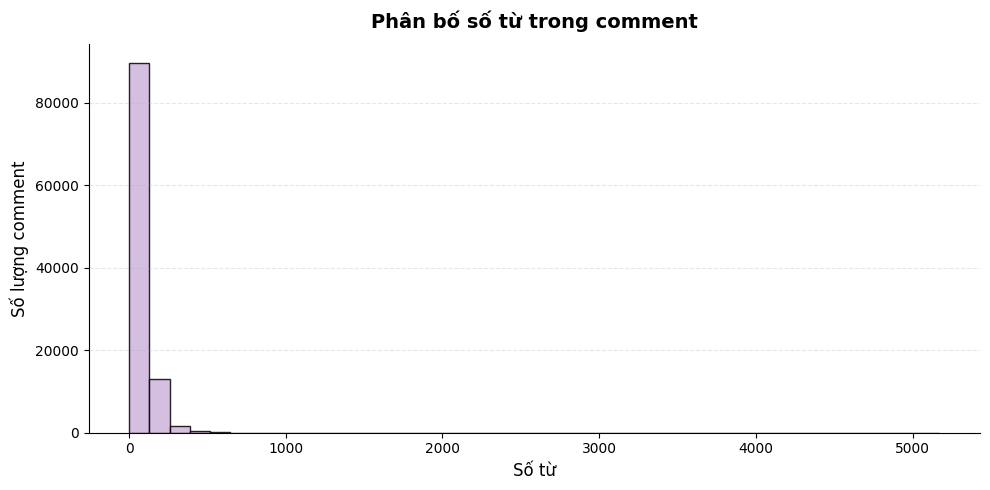

In [43]:
# Vẽ phân bố số từ trong comment 
comment_hist(raw_comments)

* Tổng kết trạng thái hiện tại của bộ dữ liệu

In [44]:
status_summary(raw_restaurants, raw_comments)

Số comment không liên kết được với quán: 0
Số quán không có comment: 4840
Số comment trùng có thể loại bỏ: 1190
Số quán trùng theo tên và địa chỉ: 6318
Số comment quá ngắn: 1644


## **11. Summary of findings**

In [45]:
summary_findings = pd.DataFrame([
            {
                "Nội dung kiểm tra": "Số dòng comment",
                "Kết quả": raw_comments.shape[0],
                "Ý nghĩa": "Quy mô dữ liệu bình luận thu thập được"
            },
            {
                "Nội dung kiểm tra": "Số dòng quán",
                "Kết quả": raw_restaurants.shape[0],
                "Ý nghĩa": "Quy mô dữ liệu quán ăn/nhà hàng thu thập được"
            },
            {
                "Nội dung kiểm tra": "Số file lỗi",
                "Kết quả": len(error_files),
                "Ý nghĩa": "Phát hiện file không đọc được"
            },
            {
                "Nội dung kiểm tra": "Số file rỗng",
                "Kết quả": len(empty_files),
                "Ý nghĩa": "Phát hiện file không có dữ liệu"
            },
            {
                "Nội dung kiểm tra": "Số comment không liên kết được với quán",
                "Kết quả": comments_without_restaurant.shape[0],
                "Ý nghĩa": "Đánh giá khả năng liên kết giữa file C và file D"
            },
            {
                "Nội dung kiểm tra": "Số quán không có comment",
                "Kết quả": restaurants_without_comments.shape[0],
                "Ý nghĩa": "Đánh giá mức độ đầy đủ của dữ liệu phản hồi"
            },
            {
                "Nội dung kiểm tra": "Số comment trùng có thể loại bỏ",
                "Kết quả": duplicate_comments_to_remove,
                "Ý nghĩa": "Đánh giá mức độ trùng lặp trong dữ liệu comment"
            },
            {
                "Nội dung kiểm tra": "Số quán trùng theo tên và địa chỉ",
                "Kết quả": duplicate_restaurants.shape[0],
                "Ý nghĩa": "Đánh giá mức độ trùng lặp trong dữ liệu quán"
            },
            {
                "Nội dung kiểm tra": "Số comment quá ngắn",
                "Kết quả": short_comments.shape[0],
                "Ý nghĩa": "Đánh giá chất lượng nội dung trước khi tính sentiment"
            }
        ])

display(summary_findings)

,Nội dung kiểm tra,Kết quả,Ý nghĩa
0,Số dòng comment,105310,Quy mô dữ liệu bình luận thu thập được
1,Số dòng quán,18988,Quy mô dữ liệu quán ăn/nhà hàng thu thập được
2,Số file lỗi,0,Phát hiện file không đọc được
3,Số file rỗng,39,Phát hiện file không có dữ liệu
4,Số comment không liên kết được với quán,0,Đánh giá khả năng liên kết giữa file C và file D
5,Số quán không có comment,4840,Đánh giá mức độ đầy đủ của dữ liệu phản hồi
6,Số comment trùng có thể loại bỏ,1190,Đánh giá mức độ trùng lặp trong dữ liệu comment
7,Số quán trùng theo tên và địa chỉ,6318,Đánh giá mức độ trùng lặp trong dữ liệu quán
8,Số comment quá ngắn,1644,Đánh giá chất lượng nội dung trước khi tính sentiment
